In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#load dataset

In [5]:
trader=pd.read_csv("/content/historical_data (1).csv")
sentiment=pd.read_csv("/content/fear_greed_index.csv")

/tmp/ipykernel_7970/774471818.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trader=pd.read_csv("/content/historical_data (1).csv")


#data understanding


In [6]:
print(trader.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash  \
0         0.0  0xec09451986a1874e3a9

In [7]:
print(sentiment.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


In [8]:
print(trader.shape)
print(sentiment.shape)

(46482, 16)
(2644, 4)


In [9]:
print(trader.info())
print(sentiment.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46482 entries, 0 to 46481
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           46482 non-null  object 
 1   Coin              46482 non-null  object 
 2   Execution Price   46482 non-null  float64
 3   Size Tokens       46482 non-null  float64
 4   Size USD          46482 non-null  float64
 5   Side              46482 non-null  object 
 6   Timestamp IST     46482 non-null  object 
 7   Start Position    46482 non-null  float64
 8   Direction         46482 non-null  object 
 9   Closed PnL        46482 non-null  float64
 10  Transaction Hash  46482 non-null  object 
 11  Order ID          46481 non-null  float64
 12  Crossed           46481 non-null  object 
 13  Fee               46481 non-null  float64
 14  Trade ID          46481 non-null  float64
 15  Timestamp         46481 non-null  float64
dtypes: float64(9), object(7)
memory usage: 5

In [10]:
print(trader.isnull().sum())
print(sentiment.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            1
Crossed             1
Fee                 1
Trade ID            1
Timestamp           1
dtype: int64
timestamp         0
value             0
classification    0
date              0
dtype: int64


#convert date format

In [11]:
#trader dataset
trader['Timestamp IST'] = pd.to_datetime(
    trader['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trader['Date'] = trader['Timestamp IST'].dt.date

In [12]:
#sentiment dataset
sentiment['Date'] = pd.to_datetime(
    sentiment['date']
).dt.date

#merge dataset

In [13]:
merged = pd.merge(
    trader,
    sentiment[['Date','classification']],
    on='Date',
    how='inner'
)

In [14]:
print(merged.shape)

(46476, 18)


#number of trades by sentiment

In [15]:
print(
    merged['classification'].value_counts()
)

classification
Greed            15166
Fear             12114
Extreme Greed     9355
Neutral           8095
Extreme Fear      1746
Name: count, dtype: int64


#data visualization

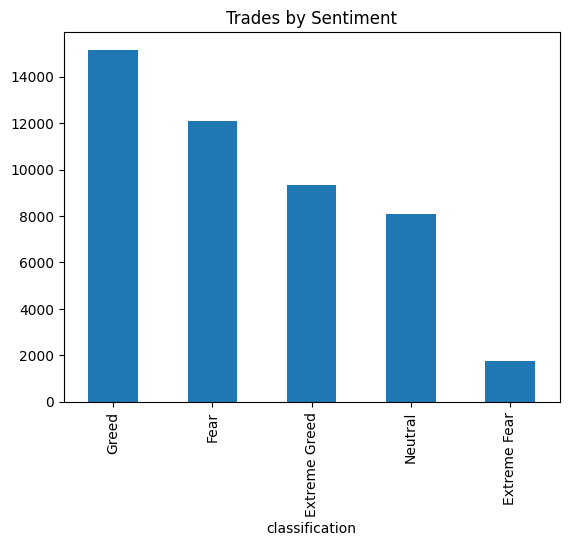

In [16]:
merged['classification'].value_counts().plot(
    kind='bar'
)

plt.title("Trades by Sentiment")
plt.show()

#average profit by sentiment


In [17]:
avg_profit = merged.groupby(
    'classification'
)['Closed PnL'].mean()

print(avg_profit)

classification
Extreme Fear     204.336799
Extreme Greed    162.746010
Fear             146.672879
Greed             92.228518
Neutral           86.191512
Name: Closed PnL, dtype: float64


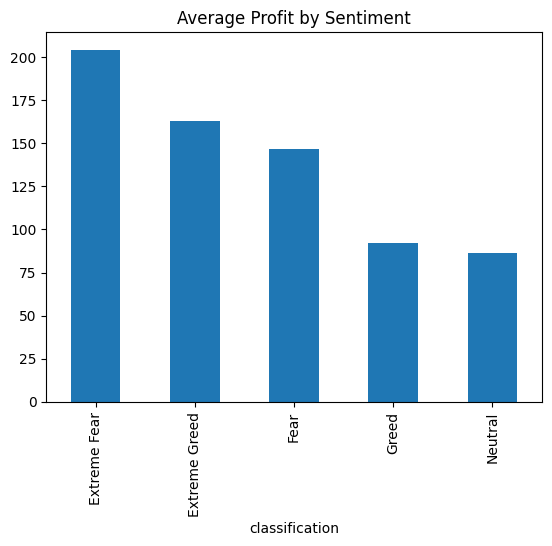

In [18]:
#graph
avg_profit.plot(kind='bar')

plt.title(
    "Average Profit by Sentiment"
)

plt.show()

#total profit by sentiment

In [19]:
total_profit = merged.groupby(
    'classification'
)['Closed PnL'].sum()

print(total_profit)

classification
Extreme Fear     3.567721e+05
Extreme Greed    1.522489e+06
Fear             1.776795e+06
Greed            1.398738e+06
Neutral          6.977203e+05
Name: Closed PnL, dtype: float64


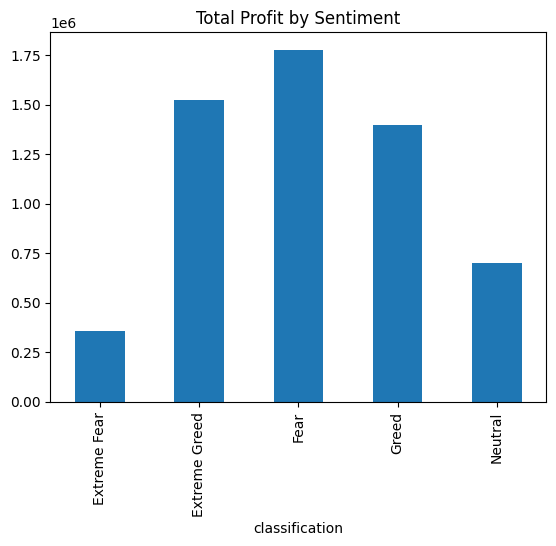

In [20]:
#graph
total_profit.plot(
    kind='bar'
)

plt.title(
    "Total Profit by Sentiment"
)

plt.show()

#buy vs sell analysais

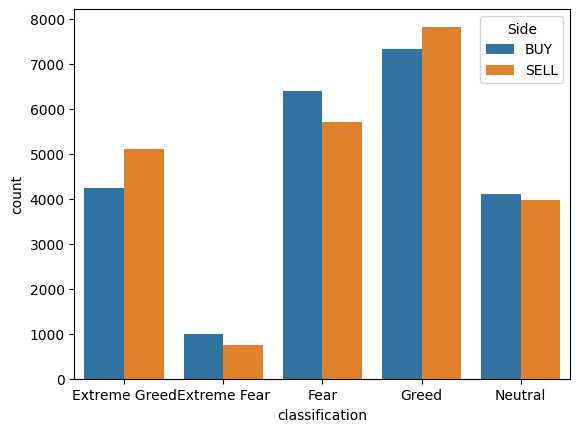

In [21]:
sns.countplot(
    x='classification',
    hue='Side',
    data=merged
)

plt.show()

#final summary table

In [22]:
summary = merged.groupby(
    'classification'
)['Closed PnL'].agg(
    ['count','mean','sum']
)

print(summary)

                count        mean           sum
classification                                 
Extreme Fear     1746  204.336799  3.567721e+05
Extreme Greed    9355  162.746010  1.522489e+06
Fear            12114  146.672879  1.776795e+06
Greed           15166   92.228518  1.398738e+06
Neutral          8095   86.191512  6.977203e+05


#conclusion

#This project analyzed the relationship between Bitcoin market sentiment and trader performance. After merging Fear & Greed data with Hyperliquid trading records, sentiment-wise profitability and trading activity were examined. The results indicate that trader performance varies across different sentiment categories, with Extreme Greed periods showing stronger profitability. These findings suggest that market sentiment can be a useful indicator for trading decisions and risk management.

Interview Question